In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
style.use('fast')
header_list = ["Cause Gene", "Effect Gene", "mean_importance"]
experiment_ID = "Col_48h_9t_RNAseq"

genes_info = pd.read_csv("C:/Users/ivana/OneDrive/Desktop/Internship New Folder/Analysis Experimental Data/genes_info.tsv", sep = "\t")
genes_name = pd.DataFrame(columns = ["regulator-target","regulator-target_names"])

k = 0
for i in range(len(genes_info)):
    for j in range(len(genes_info)):
        if genes_info["gene_id"].iloc[i] != genes_info["gene_id"].iloc[j]:
    
            genes_name.loc[k] = [f"('{genes_info['gene_id'].iloc[i]}','{genes_info['gene_id'].iloc[j]}')", f"('{genes_info['gene_name'].iloc[i]}','{genes_info['gene_name'].iloc[j]}')"]
            k = k+1

genes_name = genes_name.sort_values(by = ["regulator-target"])

In [2]:
ranking_SWING_DataFrame = pd.DataFrame()
ranking_dynGENIE3_DataFrame = pd.DataFrame()

ranking_SWING_rand_DataFrame = pd.DataFrame()
ranking_dynGENIE3_rand_DataFrame = pd.DataFrame()

ranking_SWING_crand_DataFrame = pd.DataFrame()
ranking_dynGENIE3_crand_DataFrame = pd.DataFrame()
    
end = 0
    
for j in range(100):
    
    first = end + 1
    end = end + 10
    
    ranking_dynGENIE3 = pd.read_csv(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/Analysis Experimental Data/Results_instances-1000/Results_dynGENIE3_{experiment_ID}_genes-157/Mean_Importance_{experiment_ID}/ranking_dynGENIE3_{experiment_ID}_range{first}-{end}.txt", sep = "\t",names = header_list).sort_values(by=["Cause Gene", "Effect Gene"])
    ranking_dynGENIE3_rand = pd.read_csv(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/Analysis Experimental Data/Results_instances-1000/Results_dynGENIE3_{experiment_ID}_genes-157/Mean_Importance_{experiment_ID}_rand/ranking_dynGENIE3_rand_{experiment_ID}_range{first}-{end}.txt", sep = "\t",names = header_list).sort_values(by=["Cause Gene", "Effect Gene"])
    ranking_dynGENIE3_crand = pd.read_csv(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/Analysis Experimental Data/Results_instances-1000/Results_dynGENIE3_{experiment_ID}_genes-157/Mean_Importance_{experiment_ID}_crand/ranking_dynGENIE3_crand_{experiment_ID}_range{first}-{end}.txt", sep = "\t",names = header_list).sort_values(by=["Cause Gene", "Effect Gene"])
                          
    ranking_dynGENIE3_DataFrame[f"ranking_dynGENIE3_DataFrame_{first}_{end}"] = ranking_dynGENIE3["mean_importance"].values.tolist()
    ranking_dynGENIE3_rand_DataFrame[f"ranking_dynGENIE3_rand_DataFrame_{first}_{end}"] = ranking_dynGENIE3_rand["mean_importance"].values.tolist()
    ranking_dynGENIE3_crand_DataFrame[f"ranking_dynGENIE3_crand_DataFrame_{first}_{end}"] = ranking_dynGENIE3_crand["mean_importance"].values.tolist()
    
    ranking_SWING = pd.read_csv(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/Analysis Experimental Data/Results_instances-1000/Results_SWING_{experiment_ID}_genes-157/Mean_Importance_{experiment_ID}/ranking_SWING_{experiment_ID}_range{first}-{end}.txt", sep = "\t").sort_values(by=["regulator-target"])
    ranking_SWING_DataFrame[f"ranking_SWING_DataFrame_{first}_{end}"] = ranking_SWING["mean_importance"].values.tolist()
    
    ranking_SWING_rand = pd.read_csv(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/Analysis Experimental Data/Results_instances-1000/Results_SWING_{experiment_ID}_genes-157/Mean_Importance_{experiment_ID}_rand/ranking_SWING_rand_{experiment_ID}_range{first}-{end}.txt", sep = "\t").sort_values(by=["regulator-target"])
    ranking_SWING_rand_DataFrame[f"ranking_SWING_DataFrame_{first}_{end}_rand"] = ranking_SWING_rand["mean_importance"].values.tolist()
    
    ranking_SWING_crand = pd.read_csv(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/Analysis Experimental Data/Results_instances-1000/Results_SWING_{experiment_ID}_genes-157/Mean_Importance_{experiment_ID}_crand/ranking_SWING_crand_{experiment_ID}_range{first}-{end}.txt", sep = "\t").sort_values(by=["regulator-target"])
    ranking_SWING_crand_DataFrame[f"ranking_SWING_DataFrame_{first}_{end}_crand"] = ranking_SWING_crand["mean_importance"].values.tolist()
    
    
ranking_SWING_mean = pd.DataFrame()
ranking_dynGENIE3_mean = pd.DataFrame()

ranking_SWING_rand_mean = pd.DataFrame()
ranking_dynGENIE3_rand_mean = pd.DataFrame()

ranking_SWING_crand_mean = pd.DataFrame()
ranking_dynGENIE3_crand_mean = pd.DataFrame()

ranking_SWING = pd.read_csv(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/Analysis Experimental Data/Results_instances-1000/Results_SWING_{experiment_ID}_genes-157/Mean_Importance_{experiment_ID}/ranking_SWING_{experiment_ID}_range{first}-{end}.txt", sep = "\t").sort_values(by=["regulator-target"])

ranking_SWING_mean["regulator-target"] = genes_name["regulator-target_names"].values.tolist()
ranking_dynGENIE3_mean["regulator-target"] = genes_name["regulator-target_names"].values.tolist()

ranking_SWING_rand_mean["regulator-target"] = genes_name["regulator-target_names"].values.tolist()
ranking_dynGENIE3_rand_mean["regulator-target"] = genes_name["regulator-target_names"].values.tolist()

ranking_SWING_crand_mean["regulator-target"] = genes_name["regulator-target_names"].values.tolist()
ranking_dynGENIE3_crand_mean["regulator-target"] = genes_name["regulator-target_names"].values.tolist()

ranking_SWING_mean["mean"] = ranking_SWING_DataFrame.mean(axis = 1)
ranking_dynGENIE3_mean["mean"] = ranking_dynGENIE3_DataFrame.mean(axis = 1)

ranking_SWING_rand_mean["mean"] = ranking_SWING_rand_DataFrame.mean(axis = 1)
ranking_dynGENIE3_rand_mean["mean"] = ranking_dynGENIE3_rand_DataFrame.mean(axis = 1)

ranking_SWING_crand_mean["mean"] = ranking_SWING_crand_DataFrame.mean(axis = 1)
ranking_dynGENIE3_crand_mean["mean"] = ranking_dynGENIE3_crand_DataFrame.mean(axis = 1)

ranking_SWING_mean = ranking_SWING_mean.sort_values(by = ["mean"], ascending = False)
ranking_dynGENIE3_mean = ranking_dynGENIE3_mean.sort_values(by = ["mean"], ascending = False)

ranking_SWING_rand_mean = ranking_SWING_rand_mean.sort_values(by = ["mean"], ascending = False)
ranking_dynGENIE3_rand_mean = ranking_dynGENIE3_rand_mean.sort_values(by = ["mean"], ascending = False)

ranking_SWING_crand_mean = ranking_SWING_crand_mean.sort_values(by = ["mean"], ascending = False)
ranking_dynGENIE3_crand_mean = ranking_dynGENIE3_crand_mean.sort_values(by = ["mean"], ascending = False)

## Top 10

Text(0.5, 1.0, 'dynGENIE3 Col_9t Top 10 Top 10 crand')

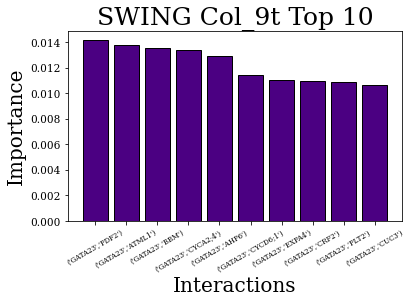

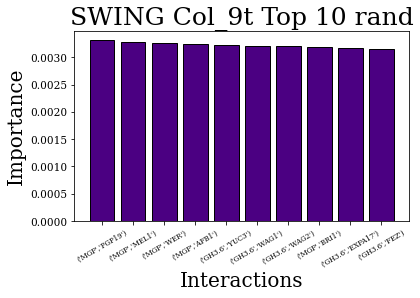

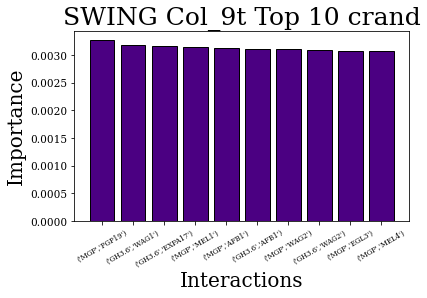

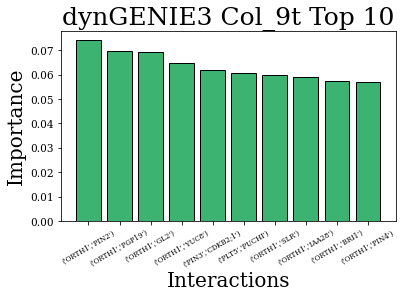

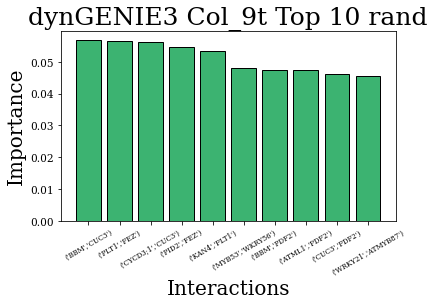

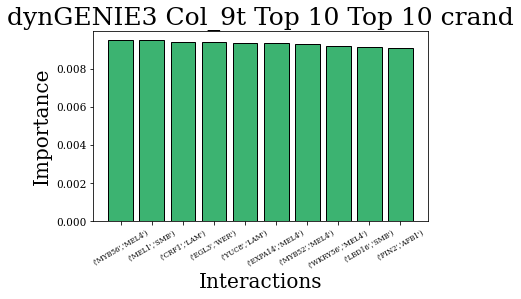

In [10]:
top = 10
barWidth = 0.8
rotation = 30
id_exp = "Col_9t"
color_SWING = "indigo"
color_dynGENIE3 = "mediumseagreen"
plt.rc('xtick', labelsize=7)
plt.rc('ytick', labelsize=10.5)
plt.rcParams["font.family"] = "serif"

#SWING
figure = plt.figure(figsize=(6,3.5))
SWING = ranking_SWING_mean["mean"].iloc[0:top].values.tolist()
SWING_regulator_target = ranking_SWING_mean["regulator-target"].iloc[0:top].values.tolist()
br1 = np.arange(len(SWING))
plt.bar(br1, SWING,color=color_SWING, width= barWidth, edgecolor= 'k', label='SWING')
plt.xticks([r  for r in range(len(SWING))], SWING_regulator_target, rotation = rotation)
plt.ylabel("Importance", fontsize = 20, family = "serif")
plt.xlabel("Interactions", fontsize = 20)
plt.title(f"SWING {id_exp} Top {top}", fontsize = 25)
plt.savefig(f"C:/Users/ivana/OneDrive/Desktop/Imagenes Internship/Top_10_predictions_SWING_experimental_{id_exp}.png", bbox_inches="tight", dpi=100 )

#SWING rand
figure = plt.figure(figsize=(6,3.5))
SWING_rand = ranking_SWING_rand_mean["mean"].iloc[0:top].values.tolist()
SWING_regulator_target_rand = ranking_SWING_rand_mean["regulator-target"].iloc[0:top].values.tolist()
br1 = np.arange(len(SWING))
plt.bar(br1, SWING_rand,color=color_SWING, width= barWidth, edgecolor= 'k', label='SWING')
plt.xticks([r  for r in range(len(SWING_rand))], SWING_regulator_target_rand, rotation = rotation)
plt.ylabel("Importance", fontsize = 20, family = "serif")
plt.xlabel("Interactions", fontsize = 20)
plt.title(f"SWING {id_exp} Top {top} rand", fontsize = 25)

#SWING crand
figure = plt.figure(figsize=(6,3.5))
SWING_crand = ranking_SWING_crand_mean["mean"].iloc[0:top].values.tolist()
SWING_regulator_target_crand = ranking_SWING_crand_mean["regulator-target"].iloc[0:top].values.tolist()
br1 = np.arange(len(SWING_crand))
plt.bar(br1, SWING_crand,color=color_SWING, width= barWidth, edgecolor= 'k', label='SWING')
plt.xticks([r  for r in range(len(SWING_crand))], SWING_regulator_target_crand, rotation = rotation)
plt.ylabel("Importance", fontsize = 20, family = "serif")
plt.xlabel("Interactions", fontsize = 20)
plt.title(f"SWING {id_exp} Top {top} crand", fontsize = 25)

#dynGENIE3
figure = plt.figure(figsize=(6,3.5))
dynGENIE3 = ranking_dynGENIE3_mean["mean"].iloc[0:top].values.tolist()
dynGENIE3_regulator_target = ranking_dynGENIE3_mean["regulator-target"].iloc[0:top].values.tolist()
br1 = np.arange(len(dynGENIE3))
plt.bar(br1, dynGENIE3,color=color_dynGENIE3, width= barWidth, edgecolor= 'k', label='SWING')
plt.xticks([r  for r in range(len(dynGENIE3))], dynGENIE3_regulator_target, rotation = rotation)
plt.ylabel("Importance", fontsize = 20, family = "serif")
plt.xlabel("Interactions", fontsize = 20)
plt.title(f"dynGENIE3 {id_exp} Top {top}", fontsize = 25)
plt.savefig(f"C:/Users/ivana/OneDrive/Desktop/Imagenes Internship/Top_10_predictions_dynGENIE3_experimental_{id_exp}.png", bbox_inches="tight", dpi=100 )

#dynGENIE3 rand
figure = plt.figure(figsize=(6,3.5))
dynGENIE3_rand = ranking_dynGENIE3_rand_mean["mean"].iloc[0:top].values.tolist()
dynGENIE3_regulator_target_rand = ranking_dynGENIE3_rand_mean["regulator-target"].iloc[0:top].values.tolist()
br1 = np.arange(len(dynGENIE3_rand))
plt.bar(br1, dynGENIE3_rand,color=color_dynGENIE3, width= barWidth, edgecolor= 'k', label='SWING')
plt.xticks([r  for r in range(len(dynGENIE3_rand))], dynGENIE3_regulator_target_rand, rotation = rotation)
plt.ylabel("Importance", fontsize = 20, family = "serif")
plt.xlabel("Interactions", fontsize = 20)
plt.title(f"dynGENIE3 {id_exp} Top {top} rand", fontsize = 25)

#dynGENIE3 crand
figure = plt.figure(figsize=(6,3.5))
dynGENIE3_crand = ranking_dynGENIE3_crand_mean["mean"].iloc[0:top].values.tolist()
dynGENIE3_regulator_target_crand = ranking_dynGENIE3_crand_mean["regulator-target"].iloc[0:top].values.tolist()
br1 = np.arange(len(dynGENIE3_crand))
plt.bar(br1, dynGENIE3_crand,color=color_dynGENIE3, width= barWidth, edgecolor= 'k', label='SWING')
plt.xticks([r  for r in range(len(dynGENIE3_crand))], dynGENIE3_regulator_target_crand, rotation = rotation)
plt.ylabel("Importance", fontsize = 20, family = "serif")
plt.xlabel("Interactions", fontsize = 20)
plt.title(f"dynGENIE3 {id_exp} Top {top} Top {top} crand", fontsize = 25)

# Selected Plots

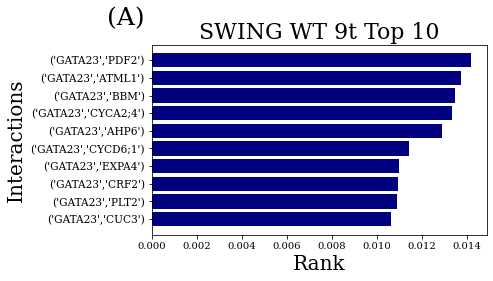

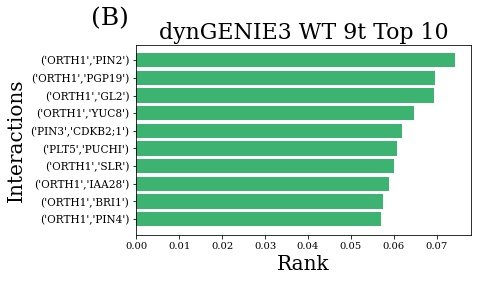

In [25]:
top = 10
barWidth = 0.8
rotation = 30
id_exp = "Col_9t"
color_SWING = "navy"
color_dynGENIE3 = "mediumseagreen"
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10.5)
plt.rcParams["font.family"] = "serif"

#SWING
figure = plt.figure(figsize=(6,3.5))
SWING = ranking_SWING_mean["mean"].iloc[0:top].values.tolist()
SWING.reverse()
SWING_regulator_target = ranking_SWING_mean["regulator-target"].iloc[0:top].values.tolist()
SWING_regulator_target.reverse()
plt.barh(SWING_regulator_target, SWING, color=color_SWING)
plt.ylabel("Interactions", fontsize = 20, family = "serif")
plt.xlabel("Rank", fontsize = 20)
plt.title(f"SWING WT 9t Top {top}", fontsize = 22)
plt.text(-0.002,11, "(A)", fontsize = 25)
plt.savefig(f"C:/Users/ivana/OneDrive/Desktop/Imagenes Internship/Top_10_predictions_SWING_experimental_{id_exp}.png", bbox_inches="tight", dpi=100 )

figure = plt.figure(figsize=(6,3.5))
dynGENIE3 = ranking_dynGENIE3_mean["mean"].iloc[0:top].values.tolist()
dynGENIE3.reverse()
dynGENIE3_regulator_target = ranking_dynGENIE3_mean["regulator-target"].iloc[0:top].values.tolist()
dynGENIE3_regulator_target.reverse()
plt.barh(dynGENIE3_regulator_target, dynGENIE3, color=color_dynGENIE3)
plt.ylabel("Interactions", fontsize = 20, family = "serif")
plt.xlabel("Rank", fontsize = 20)
plt.title(f"dynGENIE3 WT 9t Top {top}", fontsize = 22)
plt.text(-0.0105,11, "(B)", fontsize = 25)
plt.savefig(f"C:/Users/ivana/OneDrive/Desktop/Imagenes Internship/Top_10_predictions_dynGENIE3_experimental_{id_exp}.png", bbox_inches="tight", dpi=100 )
